1. Set up and GPU Check

In [1]:
import zipfile
import os

# Path to your ZIP file in your computer
zip_path = r"/Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial expression classification.zip"

# Folder where you want to extract
extract_to = r"/Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial_expression_classification"

# Create folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted successfully!")
print("Extracted files are saved in:", extract_to)

Extracted successfully!
Extracted files are saved in: /Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial_expression_classification


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else 'NOT FOUND — go to Runtime > Change runtime type > T4 GPU')

TensorFlow: 2.20.0
GPU: NOT FOUND — go to Runtime > Change runtime type > T4 GPU


Data Loading and Understanding

In [10]:
# ============================================================
#   DATASET ROOT (contains train / test / validation folders)
# ============================================================
DATA_ROOT  = '/Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial_expression_classification/facial expression classification'
DATA_DIR   = DATA_ROOT  # folder containing the split subfolders and CSVs
IMG_DIR    = DATA_ROOT  # images live under split/emotion/image.jpg
# ============================================================

IMG_SIZE    = 48
BATCH_SIZE  = 64
SEED        = 42
NUM_CLASSES = 7
EMOTIONS    = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

EP_BASELINE = 40
EP_DEEP     = 50
EP_TRANSFER = 25

In [11]:
# Load all 7 CSVs
dfs = []

# --- Start of diagnostic code ---
print(f"Checking DATA_DIR (dataset root): {DATA_DIR}")
if not os.path.exists(DATA_DIR):
    print(f"Error: The directory '{DATA_DIR}' does not exist. Please check your Google Drive path in cell 'ub0VbtdqaqlC'.")
else:
    print(f"Contents of {DATA_DIR}:")
    try:
        for item in os.listdir(DATA_DIR):
            print(f"  - {item}")
    except Exception as e:
        print(f"Error listing directory contents: {e}")
print("-" * 50)
# --- End of diagnostic code ---

validation_dir = os.path.join(DATA_DIR, 'validation')
for emotion in EMOTIONS:
    # Construct path to include the validation split subfolder
    path = os.path.join(validation_dir, f'validation_facial_{emotion}_landmarks_with_expressions.csv')
    try:
        df_e = pd.read_csv(path)
        dfs.append(df_e)
        print(f'  {emotion:10s}: {len(df_e):5d} samples')
    except FileNotFoundError:
        print(f"Error: File not found for '{emotion}' emotion at '{path}'. Please ensure the file exists and the path is correct.")
        # Break the loop if a file is not found, to prevent further errors
        break
    except Exception as e:
        print(f"An unexpected error occurred while loading {emotion} data: {e}")
        break

if dfs and len(dfs) == len(EMOTIONS): # Only proceed if all dataframes were loaded successfully
    df = pd.concat(dfs, ignore_index=True)
    print(f'\n  Total : {len(df):,} samples | {df.shape[1]} columns')
    print(f'  Missing values: {df.isnull().sum().sum()}')
    display(df[['image','expression']].sample(5, random_state=42))
elif dfs: # Some dataframes loaded, but not all
    print("\nWarning: Not all dataframes were loaded. Check the errors above.")
else:
    print("\nNo dataframes were loaded. Cannot proceed with concatenation or display.")

Checking DATA_DIR (dataset root): /Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial_expression_classification/facial expression classification
Contents of /Users/nirajkarki/Desktop/AI/Final_Coursework/Part2_VisionTask/Dataset/facial_expression_classification/facial expression classification:
  - test
  - train
  - validation
--------------------------------------------------
  angry     :   883 samples
  disgust   :   104 samples
  fear      :   962 samples
  happy     :  1778 samples
  neutral   :  1158 samples
  sad       :   995 samples
  surprise  :   769 samples

  Total : 6,649 samples | 1406 columns
  Missing values: 0


,image,expression
2387,19127.jpg,happy
1879,7182.jpg,fear
5886,10268.jpg,surprise
5532,3118.jpg,sad
4920,11234.jpg,sad


3. Visulization and EDA

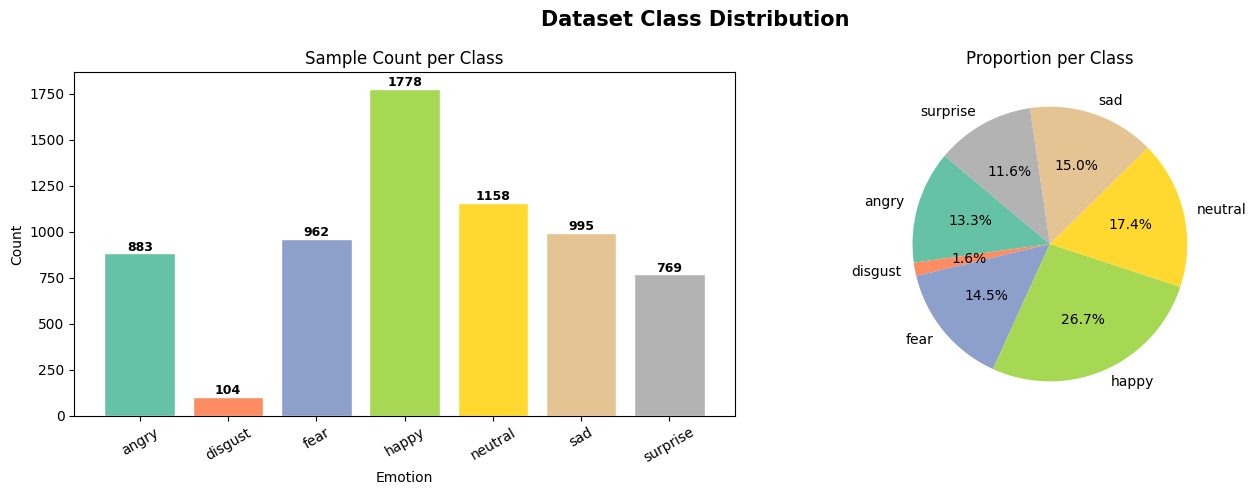

Imbalance ratio (max/min): 17.1


In [12]:
# 3.1 Class Distribution
counts = df['expression'].value_counts().reindex(EMOTIONS)
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Class Distribution', fontsize=15, fontweight='bold')

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Sample Count per Class')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 15, str(v),
                 ha='center', fontsize=9, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Proportion per Class')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Imbalance ratio (max/min):', round(counts.max()/counts.min(), 1))

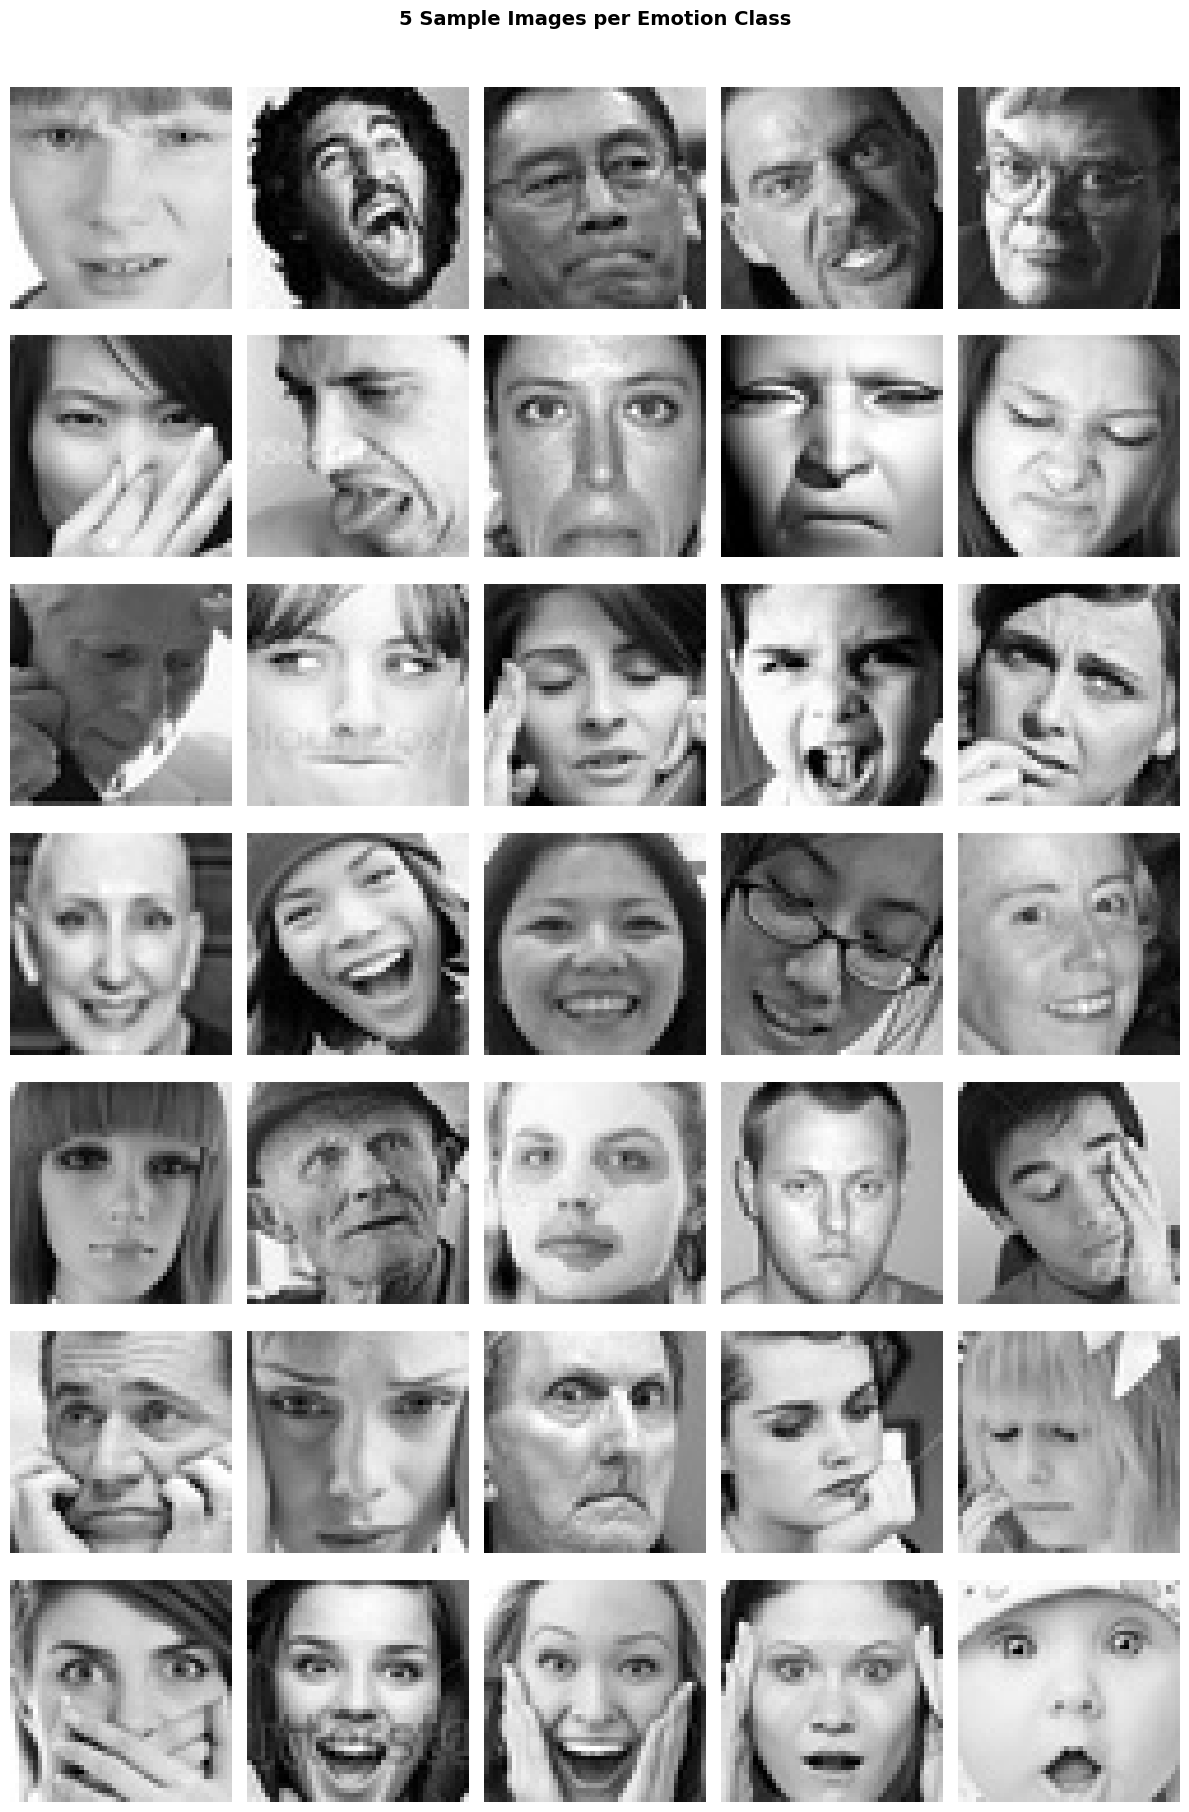

In [13]:
# 3.2 Sample images per class
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 18))
fig.suptitle('5 Sample Images per Emotion Class', fontsize=14, fontweight='bold', y=1.01)

for row_idx, emotion in enumerate(EMOTIONS):
    samples = df[df['expression'] == emotion].sample(5, random_state=42)
    for col_idx, (_, s) in enumerate(samples.iterrows()):
        # Validation images live under validation/<emotion>/<image>.
        img_path = os.path.join(IMG_DIR, 'validation', emotion, s['image'])
        try:
            img = Image.open(img_path).convert('L')
            axes[row_idx, col_idx].imshow(np.array(img), cmap='gray')
            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(
                    emotion.capitalize(), fontsize=11, fontweight='bold',
                    rotation=0, labelpad=55, va='center')
        except FileNotFoundError:
            print(f"Error: Image file not found for {s['image']} at {img_path}")
            axes[row_idx, col_idx].text(0.5, 0.5, 'Image not found',
                                       horizontalalignment='center',
                                       verticalalignment='center',
                                       transform=axes[row_idx, col_idx].transAxes, color='red')
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()

4. Preprocessing and Augmentation

In [14]:
# 4.1 Load images into numpy arrays
print('Loading images...')
X_list, y_list = [], []
missing = 0

for _, row in df.iterrows():
    # Load validation split images from validation/<emotion>/<image>.
    path = os.path.join(IMG_DIR, 'validation', row['expression'], row['image'])
    if not os.path.exists(path):
        missing += 1
        continue
    img = np.array(Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    X_list.append(img)
    y_list.append(row['expression'])

X = np.array(X_list, dtype=np.float32)
print(f'Loaded: {len(X):,} | Missing: {missing}')

Loading images...
Loaded: 6,649 | Missing: 0


In [15]:
# 4.2 Normalize + encode labels
X = X / 255.0

le = LabelEncoder()
le.fit(EMOTIONS)
y_enc = le.transform(y_list)
y_cat = to_categorical(y_enc, NUM_CLASSES)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print('X shape:', X.shape, '| y shape:', y_cat.shape)

X shape: (6649, 48, 48, 1) | y shape: (6649, 7)


In [16]:
# 4.3 Train / Val / Test split (70% / 15% / 15%)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=SEED, stratify=y_enc)
y_tmp_int = np.argmax(y_tmp, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=SEED, stratify=y_tmp_int)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 4,656 | Val: 995 | Test: 998


In [17]:
# 4.4 Class weights (handle imbalance)
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_int)
class_weights = dict(enumerate(cw))
print('Class weights:')
for i, w in class_weights.items():
    print(f'  {le.classes_[i]:10s}: {w:.3f}')

Class weights:
  angry     : 1.076
  disgust   : 9.238
  fear      : 0.987
  happy     : 0.534
  neutral   : 0.820
  sad       : 0.954
  surprise  : 1.234


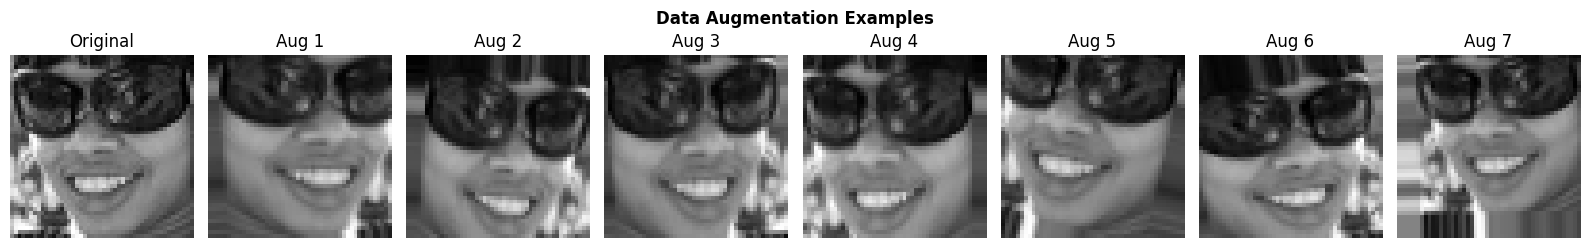

In [18]:
# 4.5 Augmentation generator
train_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.05
)
train_gen.fit(X_train)

# Visualize augmentations
sample = X_train[0:1]
aug_iter = train_gen.flow(sample, batch_size=1)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
fig.suptitle('Data Augmentation Examples', fontsize=12, fontweight='bold')
axes[0].imshow(sample[0].reshape(IMG_SIZE,IMG_SIZE), cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 8):
    aug = next(aug_iter)[0].reshape(IMG_SIZE, IMG_SIZE)
    axes[i].imshow(aug, cmap='gray')
    axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

The code below loads the images, converts them to numpy arrays, and stores them in `X_list`. It then converts `X_list` to a numpy array `X`.

In [19]:
# 4.1 Load images into numpy arrays
print('Loading images...')
X_list, y_list = [], []
missing = 0

for _, row in df.iterrows():
    # Load validation split images from validation/<emotion>/<image>.
    path = os.path.join(IMG_DIR, 'validation', row['expression'], row['image'])
    if not os.path.exists(path):
        missing += 1
        continue
    img = np.array(Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    X_list.append(img)
    y_list.append(row['expression'])

X = np.array(X_list, dtype=np.float32)
print(f'Loaded: {len(X):,} | Missing: {missing}')

Loading images...
Loaded: 6,649 | Missing: 0


This next block normalizes the image data in `X` and reshapes it to the format required by the CNN model.

In [20]:
# 4.2 Normalize + encode labels
X = X / 255.0

le = LabelEncoder()
le.fit(EMOTIONS)
y_enc = le.transform(y_list)
y_cat = to_categorical(y_enc, NUM_CLASSES)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print('X shape:', X.shape, '| y shape:', y_cat.shape)

X shape: (6649, 48, 48, 1) | y shape: (6649, 7)


5. Part A - Baseline CNN

In [21]:
# Helper functions
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history.history['loss'],         label='Train', color='royalblue')
    axes[0].plot(history.history['val_loss'],      label='Val',   color='tomato', ls='--')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Val',   color='tomato', ls='--')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(title.lower().replace(' ','_') + '.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate_model(model, Xt, yt, name):
    yp = np.argmax(model.predict(Xt, verbose=0), axis=1)
    yt_int = np.argmax(yt, axis=1)
    acc = np.mean(yp == yt_int)
    print(f'\n{name} — Test Accuracy: {acc*100:.2f}%')
    print(classification_report(yt_int, yp, target_names=EMOTIONS))
    fig, ax = plt.subplots(figsize=(8,6))
    ConfusionMatrixDisplay(confusion_matrix(yt_int, yp), display_labels=EMOTIONS).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.xticks(rotation=30); plt.tight_layout()
    plt.savefig(f'cm_{name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, yp, yt_int

In [22]:
def build_baseline(input_shape=(48,48,1), nc=7):
    m = models.Sequential(name='Baseline_CNN')
    m.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Flatten())
    m.add(layers.Dense(256, activation='relu'))
    m.add(layers.Dense(128, activation='relu'))
    m.add(layers.Dense(64,  activation='relu'))
    m.add(layers.Dense(nc,  activation='softmax'))
    return m

baseline = build_baseline()
baseline.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cb_b = [
    callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6),
    callbacks.ModelCheckpoint('best_baseline.keras', save_best_only=True)
]

t0 = time.time()
hist_b = baseline.fit(
    train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EP_BASELINE, callbacks=cb_b,
    class_weight=class_weights, verbose=1
)
t_b = time.time() - t0
print(f'Baseline training time: {t_b/60:.1f} min')

Epoch 1/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.1971 - loss: 1.9006 - val_accuracy: 0.1266 - val_loss: 1.9635 - learning_rate: 0.0010
Epoch 2/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.1670 - loss: 1.9418 - val_accuracy: 0.1518 - val_loss: 1.9259 - learning_rate: 0.0010
Epoch 3/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.1542 - loss: 1.9539 - val_accuracy: 0.1759 - val_loss: 1.9193 - learning_rate: 0.0010
Epoch 4/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2363 - loss: 1.9091 - val_accuracy: 0.1628 - val_loss: 1.9397 - learning_rate: 0.0010
Epoch 5/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1835 - loss: 1.9054 - val_accuracy: 0.2211 - val_loss: 1.8700 - learning_rate: 0.0010
Epoch 6/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1834 - loss: 1.8740 - val_accuracy: 0.2080 - val_loss: 1.8699 - learning_rate: 0.0010
Epoch 7/40
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1899 - loss: 1.8419 - val_acc

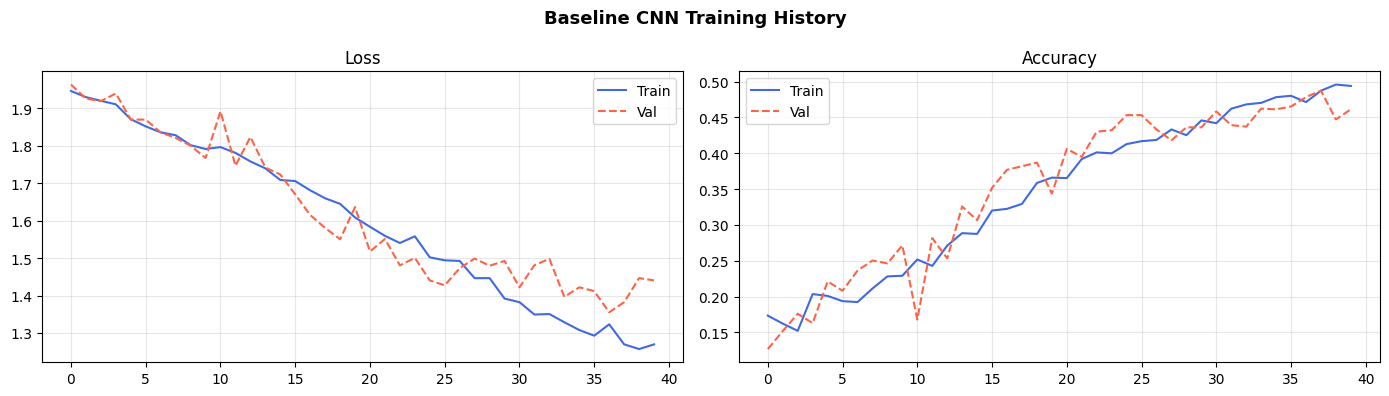


Baseline CNN — Test Accuracy: 48.60%
              precision    recall  f1-score   support

       angry       0.39      0.25      0.30       133
     disgust       0.18      0.62      0.28        16
        fear       0.35      0.17      0.23       144
       happy       0.71      0.68      0.70       267
     neutral       0.40      0.65      0.49       174
         sad       0.37      0.28      0.31       149
    surprise       0.60      0.71      0.65       115

    accuracy                           0.49       998
   macro avg       0.43      0.48      0.42       998
weighted avg       0.49      0.49      0.47       998



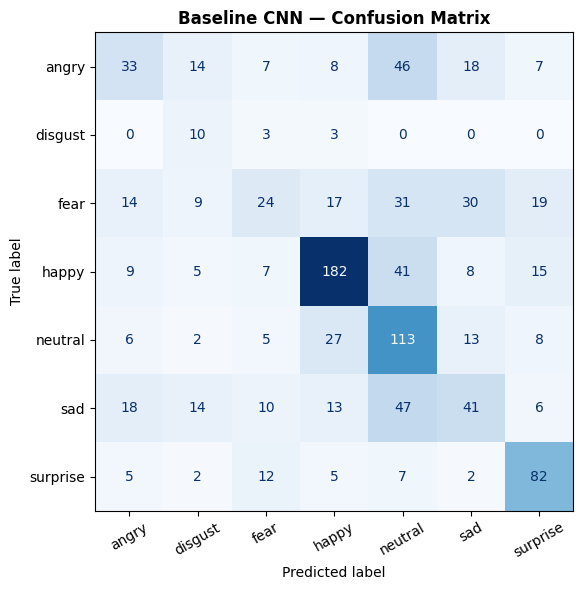

In [24]:
plot_history(hist_b, 'Baseline CNN Training History')
acc_b, pred_b, true_b = evaluate_model(baseline, X_test, y_test, 'Baseline CNN')

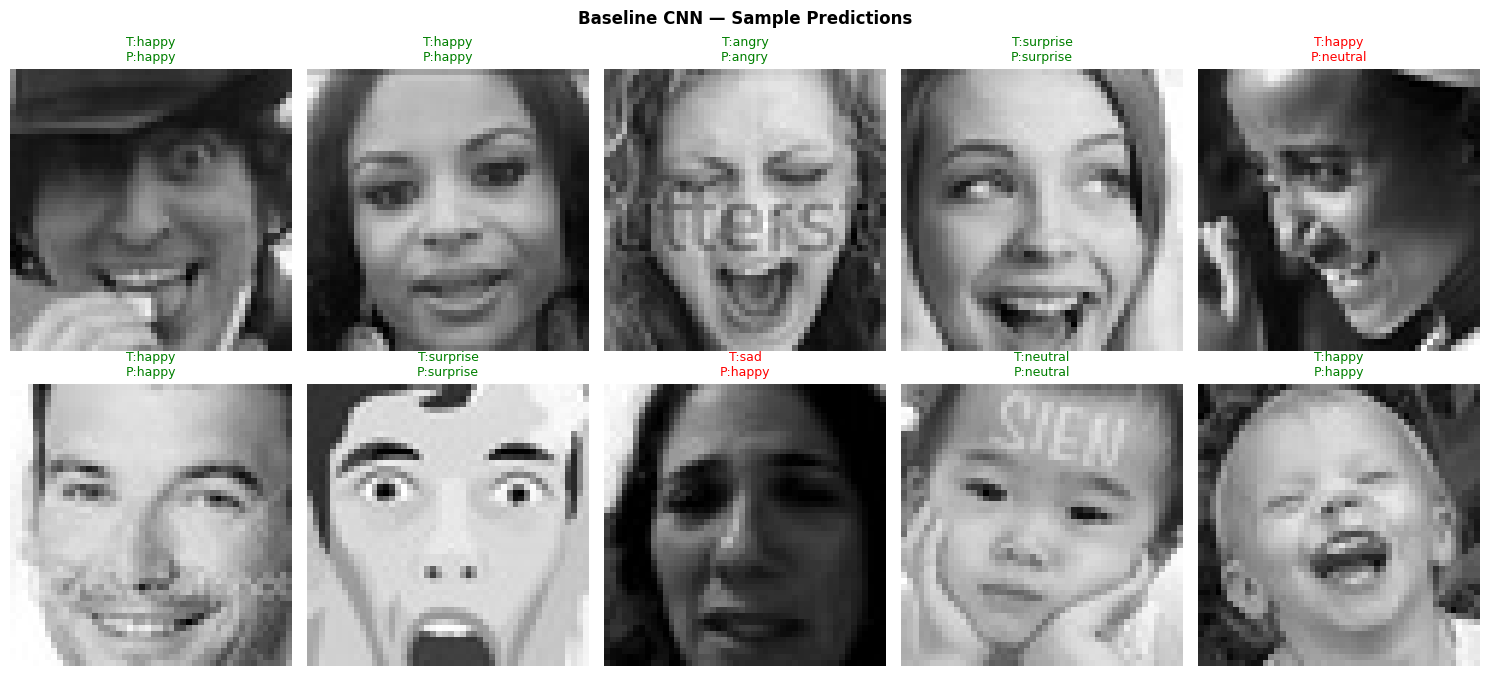

In [25]:
# Inference visualization
idx = np.random.choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Baseline CNN — Sample Predictions', fontweight='bold')
for i, ax in enumerate(axes.flat):
    img  = X_test[idx[i]].reshape(IMG_SIZE, IMG_SIZE)
    true = le.classes_[np.argmax(y_test[idx[i]])]
    pred = le.classes_[pred_b[idx[i]]]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'T:{true}\nP:{pred}', color='green' if true==pred else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

6. Part A — Deeper CNN with Regularization

In [26]:
def build_deep(input_shape=(48,48,1), nc=7):
    m = models.Sequential(name='Deep_CNN')

    for filters in [64, 128, 256]:
        m.add(layers.Conv2D(filters, (3,3), padding='same',
                            input_shape=input_shape if filters==64 else (None,)))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation('relu'))
        m.add(layers.Conv2D(filters, (3,3), padding='same'))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation('relu'))
        m.add(layers.MaxPooling2D((2,2)))
        m.add(layers.Dropout(0.25))

    m.add(layers.Flatten())
    m.add(layers.Dense(512, kernel_regularizer=regularizers.l2(1e-3)))
    m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-3)))
    m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
    m.add(layers.Dropout(0.4))
    m.add(layers.Dense(128, activation='relu'))
    m.add(layers.Dense(nc, activation='softmax'))
    return m

deep_adam = build_deep()
deep_adam.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 256)    │             

 Total params: 6,035,143 (23.02 MB)

 Trainable params: 6,031,815 (23.01 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [27]:
deep_adam.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_d = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_deep_adam.keras', save_best_only=True)
]

t0 = time.time()
hist_da = deep_adam.fit(
    train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EP_DEEP, callbacks=cb_d,
    class_weight=class_weights, verbose=1
)
t_da = time.time() - t0
print(f'Deep CNN (Adam) time: {t_da/60:.1f} min')

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 498ms/step - accuracy: 0.1582 - loss: 3.5962 - val_accuracy: 0.1739 - val_loss: 3.2896 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 577ms/step - accuracy: 0.1784 - loss: 3.3874 - val_accuracy: 0.2673 - val_loss: 3.2419 - learning_rate: 0.0010
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 52s 710ms/step - accuracy: 0.1808 - loss: 3.1761 - val_accuracy: 0.0894 - val_loss: 3.0830 - learning_rate: 0.0010
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 51s 702ms/step - accuracy: 0.1693 - loss: 3.0152 - val_accuracy: 0.1809 - val_loss: 2.9656 - learning_rate: 0.0010
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 49s 673ms/step - accuracy: 0.2014 - loss: 2.8488 - val_accuracy: 0.2724 - val_loss: 2.7717 - learning_rate: 0.0010
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 643ms/step - accuracy: 0.1993 - loss: 2.7487 - val_accuracy: 0.2874 - val_loss: 2.6128 - learning_rate: 0.0010
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 624ms/step - accuracy: 0.2293 - loss: 2.

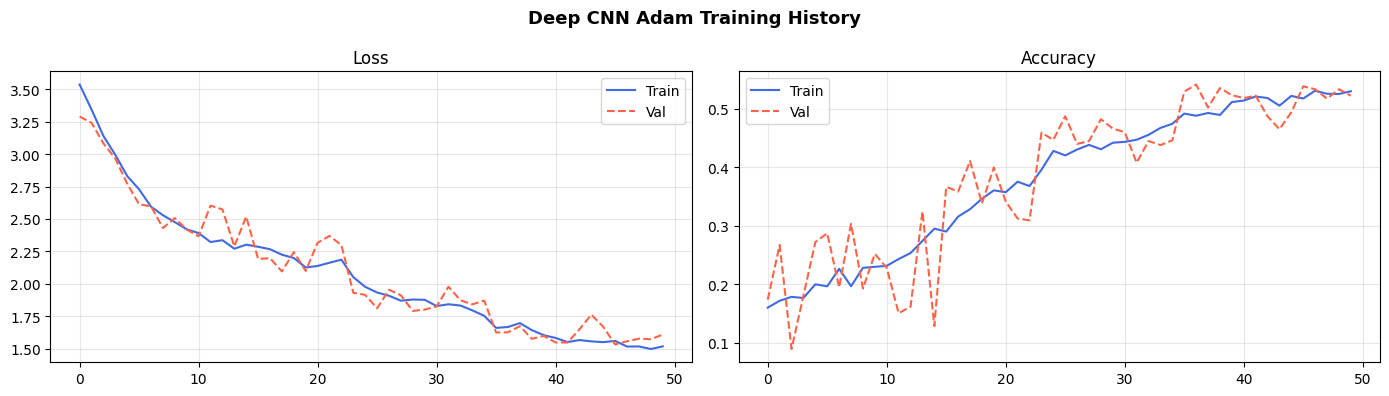


Deep CNN Adam — Test Accuracy: 53.31%
              precision    recall  f1-score   support

       angry       0.46      0.38      0.42       133
     disgust       0.16      0.38      0.22        16
        fear       0.41      0.19      0.26       144
       happy       0.85      0.70      0.77       267
     neutral       0.42      0.71      0.53       174
         sad       0.37      0.36      0.36       149
    surprise       0.65      0.73      0.69       115

    accuracy                           0.53       998
   macro avg       0.48      0.49      0.47       998
weighted avg       0.56      0.53      0.53       998



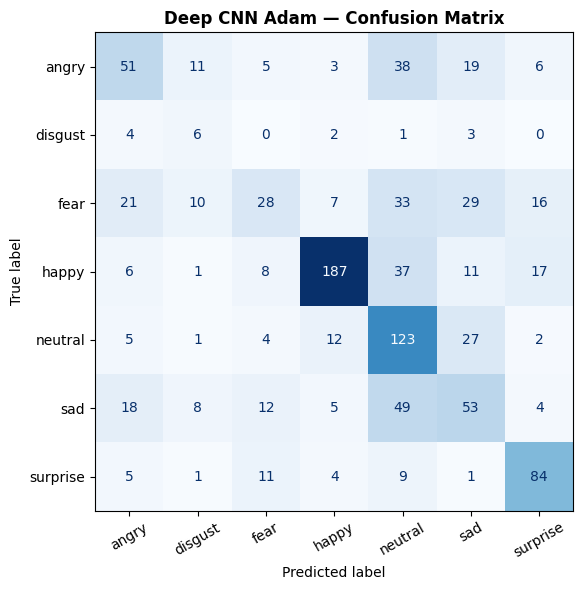

In [28]:
plot_history(hist_da, 'Deep CNN Adam Training History')
acc_da, pred_da, true_da = evaluate_model(deep_adam, X_test, y_test, 'Deep CNN Adam')

7. Part A — Experimentation & Comparative Analysis

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 406ms/step - accuracy: 0.1601 - loss: 3.4070 - val_accuracy: 0.0704 - val_loss: 3.2793 - learning_rate: 0.0100
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 32s 436ms/step - accuracy: 0.1412 - loss: 3.3091 - val_accuracy: 0.0161 - val_loss: 3.2703 - learning_rate: 0.0100
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 446ms/step - accuracy: 0.1720 - loss: 3.1816 - val_accuracy: 0.0181 - val_loss: 3.2173 - learning_rate: 0.0100
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 535ms/step - accuracy: 0.1524 - loss: 3.1934 - val_accuracy: 0.2653 - val_loss: 3.1390 - learning_rate: 0.0100
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 607ms/step - accuracy: 0.1747 - loss: 3.1308 - val_accuracy: 0.2472 - val_loss: 3.1129 - learning_rate: 0.0100
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 572ms/step - accuracy: 0.1626 - loss: 3.1285 - val_accuracy: 0.2533 - val_loss: 3.0482 - learning_rate: 0.0100
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 544ms/step - accuracy: 0.1985 - loss: 3.

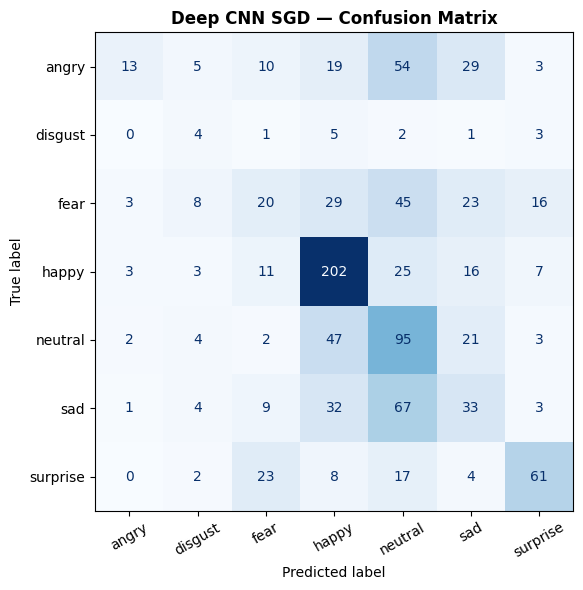

In [30]:
# 7.1 Deep CNN with SGD
deep_sgd = build_deep()
deep_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
hist_ds = deep_sgd.fit(
    train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EP_DEEP,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True),
               callbacks.ReduceLROnPlateau(patience=5, factor=0.5)],
    class_weight=class_weights, verbose=1
)
t_ds = time.time() - t0
print(f'Deep CNN (SGD) time: {t_ds/60:.1f} min')
acc_ds, pred_ds, true_ds = evaluate_model(deep_sgd, X_test, y_test, 'Deep CNN SGD')

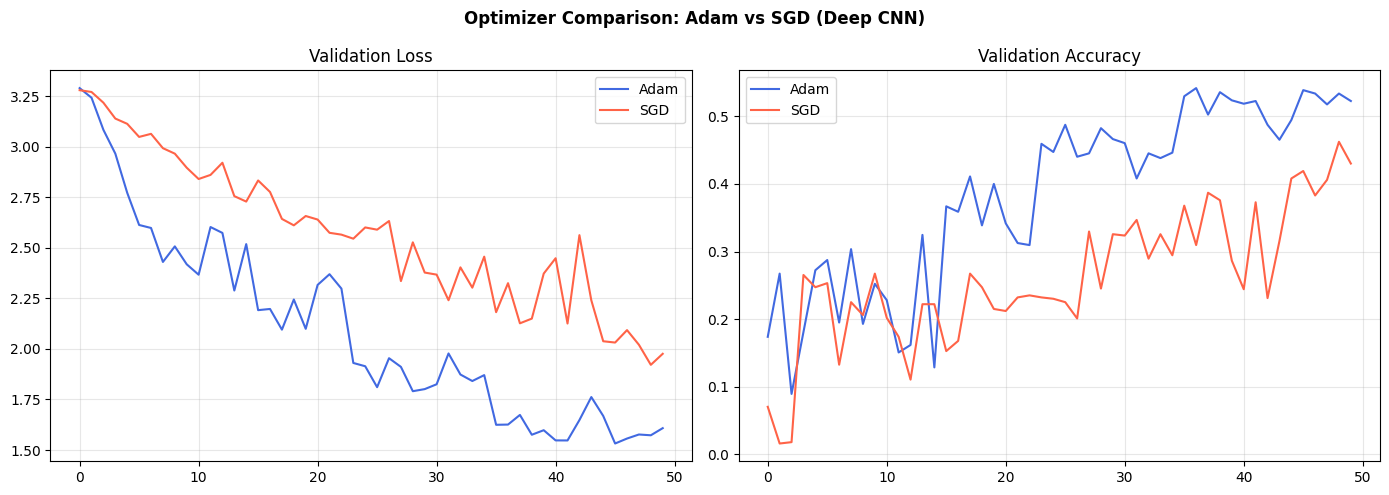

In [33]:
# 7.2 Optimizer comparison plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: Adam vs SGD (Deep CNN)', fontweight='bold')
axes[0].plot(hist_da.history['val_loss'], label='Adam', color='royalblue')
axes[0].plot(hist_ds.history['val_loss'], label='SGD',  color='tomato')
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(hist_da.history['val_accuracy'], label='Adam', color='royalblue')
axes[1].plot(hist_ds.history['val_accuracy'], label='SGD',  color='tomato')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 340ms/step - accuracy: 0.0479 - loss: 2.0906 - val_accuracy: 0.1739 - val_loss: 1.9415
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 350ms/step - accuracy: 0.2263 - loss: 1.9012 - val_accuracy: 0.1497 - val_loss: 1.9433
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 359ms/step - accuracy: 0.1394 - loss: 1.9060 - val_accuracy: 0.1447 - val_loss: 1.9451
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 27s 372ms/step - accuracy: 0.1486 - loss: 1.9084 - val_accuracy: 0.1447 - val_loss: 1.9456
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 29s 399ms/step - accuracy: 0.1236 - loss: 1.9457 - val_accuracy: 0.1497 - val_loss: 1.9470
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 32s 445ms/step - accuracy: 0.1072 - loss: 1.9641 - val_accuracy: 0.1327 - val_loss: 1.9455
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 464ms/step - accuracy: 0.1189 - loss: 1.9680 - val_accuracy: 0.1447 - val_loss: 1.9462

Ablation NoReg — Test Accuracy: 17.43%
              precision    recall  f1-score   support

  

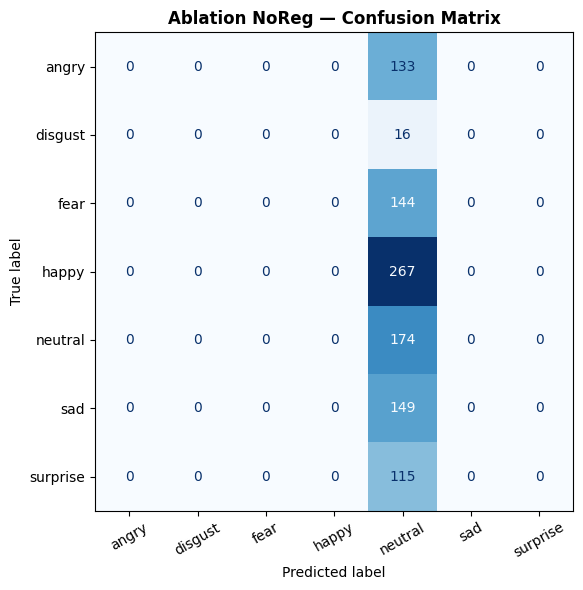

In [34]:
# 7.3 Ablation Study — remove Dropout & BatchNorm
def build_ablation(input_shape=(48,48,1), nc=7):
    m = models.Sequential(name='Ablation_NoReg')
    m.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same', input_shape=input_shape))
    m.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dense(256, activation='relu'))
    m.add(layers.Dense(128, activation='relu'))
    m.add(layers.Dense(nc, activation='softmax'))
    return m

abl = build_ablation()
abl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_abl = abl.fit(
    train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val), epochs=25,
    callbacks=[callbacks.EarlyStopping(patience=6, restore_best_weights=True)],
    class_weight=class_weights, verbose=1
)
acc_abl, _, _ = evaluate_model(abl, X_test, y_test, 'Ablation NoReg')

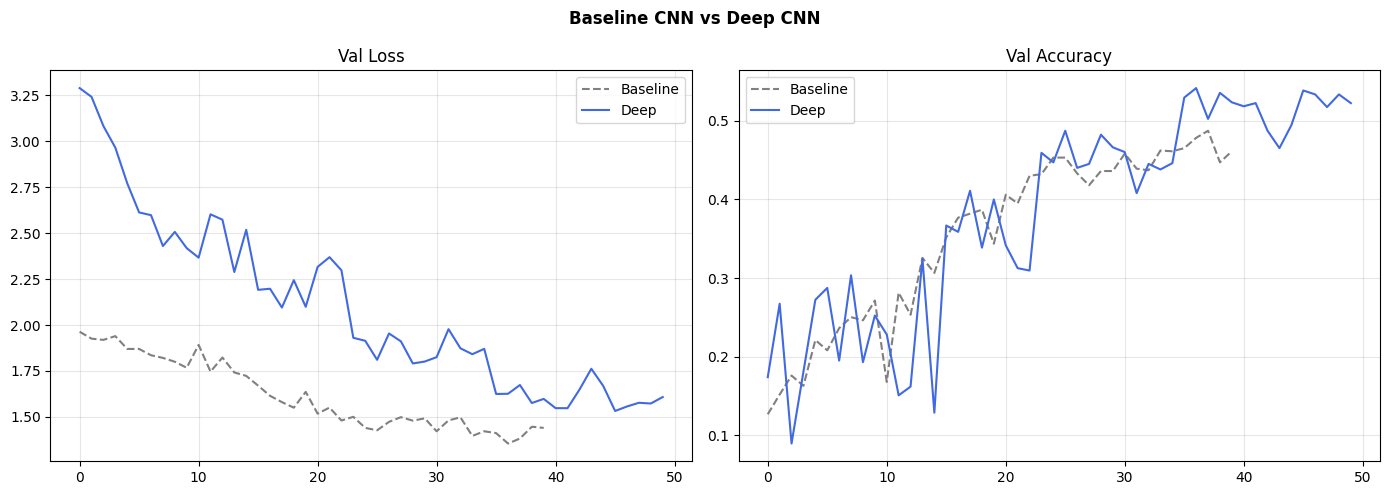

In [35]:
# 7.4 Baseline vs Deep comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN vs Deep CNN', fontweight='bold')
axes[0].plot(hist_b.history['val_loss'],  label='Baseline', color='gray', ls='--')
axes[0].plot(hist_da.history['val_loss'], label='Deep',     color='royalblue')
axes[0].set_title('Val Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(hist_b.history['val_accuracy'],  label='Baseline', color='gray', ls='--')
axes[1].plot(hist_da.history['val_accuracy'], label='Deep',     color='royalblue')
axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_vs_deep.png', dpi=150, bbox_inches='tight')
plt.show()

8. Part B — Transfer Learning (MobileNetV2)

In [36]:
print(f"Is X defined? {'X' in locals() or 'X' in globals()}")
if 'X' in locals() or 'X' in globals():
    print('Shape of X:', X.shape)
else:
    print('X is not defined. Please ensure all cells from the beginning are run.')

Is X defined? True
Shape of X: (6649, 48, 48, 1)


In [37]:
# 8.1 Prepare data: resize 48→96, grayscale→RGB
TL_SIZE = 224
print('Resizing images to 96x96 RGB for MobileNetV2...')
X_tl = []
for img_arr in X.reshape(-1, IMG_SIZE, IMG_SIZE):
    pil = Image.fromarray((img_arr*255).astype(np.uint8)).convert('RGB').resize((TL_SIZE,TL_SIZE))
    X_tl.append(np.array(pil))
X_tl = np.array(X_tl, dtype=np.float32)
print('TL data shape:', X_tl.shape)

y_tl_int = np.argmax(y_cat[:len(X_tl)], axis=1)
Xtl_tmp, Xtl_test, ytl_tmp, ytl_test = train_test_split(
    X_tl, y_cat[:len(X_tl)], test_size=0.15, random_state=SEED, stratify=y_tl_int)
ytl_tmp_int = np.argmax(ytl_tmp, axis=1)
Xtl_train, Xtl_val, ytl_train, ytl_val = train_test_split(
    Xtl_tmp, ytl_tmp, test_size=0.176, random_state=SEED, stratify=ytl_tmp_int)
print(f'TL Train: {len(Xtl_train):,} | Val: {len(Xtl_val):,} | Test: {len(Xtl_test):,}')

Resizing images to 96x96 RGB for MobileNetV2...
TL data shape: (6649, 224, 224, 3)
TL Train: 4,656 | Val: 995 | Test: 998


In [38]:
# 8.2 Build MobileNetV2 model
base = MobileNetV2(input_shape=(TL_SIZE,TL_SIZE,3), include_top=False, weights='imagenet')
base.trainable = False  # Phase 1: frozen

inp = tf.keras.Input(shape=(TL_SIZE, TL_SIZE, 3))
x   = tf.keras.applications.mobilenet_v2.preprocess_input(inp)
x   = base(x, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = tf.keras.Model(inp, out, name='MobileNetV2_TL')
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
# 8.3 Phase 1 — Feature Extraction
tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])

tl_aug = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1)

cb_tl = [
    callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_tl.keras', save_best_only=True)
]

t0 = time.time()
hist_tl1 = tl_model.fit(
    tl_aug.flow(Xtl_train, ytl_train, batch_size=BATCH_SIZE),
    validation_data=(Xtl_val, ytl_val),
    epochs=EP_TRANSFER, callbacks=cb_tl,
    class_weight=class_weights, verbose=1
)
t_tl1 = time.time() - t0
print(f'Phase 1 time: {t_tl1/60:.1f} min')

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 350ms/step - accuracy: 0.1636 - loss: 2.1379 - val_accuracy: 0.2744 - val_loss: 1.8566 - learning_rate: 0.0010
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 27s 368ms/step - accuracy: 0.2163 - loss: 1.9052 - val_accuracy: 0.3528 - val_loss: 1.7327 - learning_rate: 0.0010
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 377ms/step - accuracy: 0.2684 - loss: 1.7893 - val_accuracy: 0.3598 - val_loss: 1.7136 - learning_rate: 0.0010
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.2864 - loss: 1.7567 - val_accuracy: 0.3719 - val_loss: 1.6849 - learning_rate: 0.0010
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 35s 474ms/step - accuracy: 0.2759 - loss: 1.7389 - val_accuracy: 0.3910 - val_loss: 1.6549 - learning_rate: 0.0010
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 526ms/step - accuracy: 0.3061 - loss: 1.6936 - val_accuracy: 0.4201 - val_loss: 1.5795 - learning_rate: 0.0010
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 551ms/step - accuracy: 0.3367 - loss: 1.

In [40]:
# 8.4 Phase 2 — Fine-Tuning (unfreeze top 30 layers)
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR to avoid catastrophic forgetting
    loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
hist_tl2 = tl_model.fit(
    tl_aug.flow(Xtl_train, ytl_train, batch_size=BATCH_SIZE),
    validation_data=(Xtl_val, ytl_val),
    epochs=EP_TRANSFER, callbacks=cb_tl,
    class_weight=class_weights, verbose=1
)
t_tl2 = time.time() - t0
t_tl  = t_tl1 + t_tl2
print(f'Phase 2 time: {t_tl2/60:.1f} min | Total TL: {t_tl/60:.1f} min')

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 447ms/step - accuracy: 0.3138 - loss: 2.0279 - val_accuracy: 0.4854 - val_loss: 1.3431 - learning_rate: 1.0000e-05
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 465ms/step - accuracy: 0.3404 - loss: 1.8521 - val_accuracy: 0.4834 - val_loss: 1.3553 - learning_rate: 1.0000e-05
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 543ms/step - accuracy: 0.3551 - loss: 1.7033 - val_accuracy: 0.4643 - val_loss: 1.3734 - learning_rate: 1.0000e-05
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 622ms/step - accuracy: 0.3691 - loss: 1.6396 - val_accuracy: 0.4593 - val_loss: 1.3948 - learning_rate: 1.0000e-05
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 49s 664ms/step - accuracy: 0.3861 - loss: 1.5560 - val_accuracy: 0.4573 - val_loss: 1.4057 - learning_rate: 1.0000e-05
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 586ms/step - accuracy: 0.3978 - loss: 1.5057 - val_accuracy: 0.4633 - val_loss: 1.3928 - learning_rate: 5.0000e-06
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 591ms/step - acc

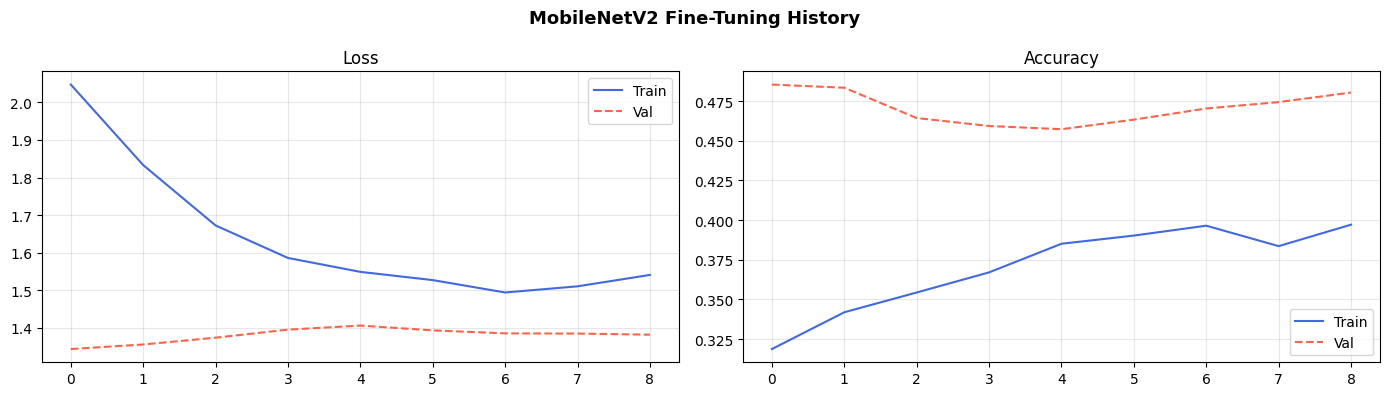


MobileNetV2 TL — Test Accuracy: 48.80%
              precision    recall  f1-score   support

       angry       0.45      0.26      0.33       133
     disgust       0.06      0.06      0.06        16
        fear       0.45      0.13      0.20       144
       happy       0.57      0.76      0.65       267
     neutral       0.40      0.53      0.46       174
         sad       0.44      0.38      0.41       149
    surprise       0.56      0.69      0.61       115

    accuracy                           0.49       998
   macro avg       0.42      0.40      0.39       998
weighted avg       0.48      0.49      0.46       998



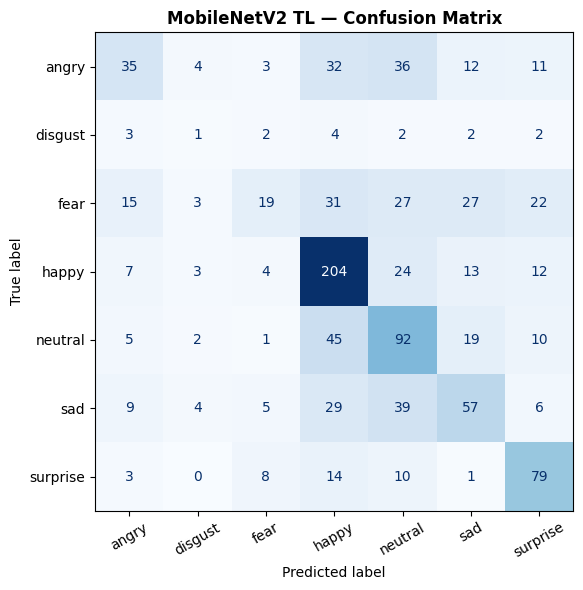

In [41]:
plot_history(hist_tl2, 'MobileNetV2 Fine-Tuning History')
acc_tl, pred_tl, true_tl = evaluate_model(tl_model, Xtl_test, ytl_test, 'MobileNetV2 TL')

9. Final Summary & Comparison

In [42]:
# Final results table
results = pd.DataFrame({
    'Model'             : ['Baseline CNN', 'Deep CNN (Adam)', 'Deep CNN (SGD)',
                           'Ablation (No Reg)', 'MobileNetV2 TL'],
    'Test Accuracy (%)'  : [f'{acc_b*100:.2f}', f'{acc_da*100:.2f}', f'{acc_ds*100:.2f}',
                            f'{acc_abl*100:.2f}', f'{acc_tl*100:.2f}'],
    'Training Time'      : [f'{t_b/60:.1f}m', f'{t_da/60:.1f}m', f'{t_ds/60:.1f}m',
                            'N/A', f'{t_tl/60:.1f}m'],
    'Parameters'         : [f'{baseline.count_params():,}', f'{deep_adam.count_params():,}',
                            f'{deep_sgd.count_params():,}', f'{abl.count_params():,}',
                            f'{tl_model.count_params():,}'],
    'Regularization'     : ['None', 'BN+Dropout+L2', 'BN+Dropout+L2', 'None', 'Dropout+ImageNet']
})
print('=== FINAL RESULTS SUMMARY ===')
display(results)

=== FINAL RESULTS SUMMARY ===


,Model,Test Accuracy (%),Training Time,Parameters,Regularization
0,Baseline CNN,48.60,1.8m,"1,314,183",None
1,Deep CNN (Adam),53.31,36.7m,"6,035,143",BN+Dropout+L2
2,Deep CNN (SGD),42.89,34.2m,"6,035,143",BN+Dropout+L2
3,Ablation (No Reg),17.43,N/A,"6,028,487",None
4,MobileNetV2 TL,48.80,21.3m,"2,619,719",Dropout+ImageNet
